In [1]:
! [ -e /content ] && pip install -Uqq fastbook
import fastbook
fastbook.setup_book()
from fastai.vision.all import *
from fastbook import *

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 10.8 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.1/124.1 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.9/246.9 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 48.8 MB/s eta 0:00:00


kernel for our model

In [2]:
top_edge = tensor([[-1,-1,-1],
                   [ 0, 0, 0],
                   [ 1, 1, 1]]).float()

Loading the image

In [3]:
path = untar_data(URLs.MNIST_SAMPLE)
path

<div><progress max="3214948" value="3219456"></progress> 100.14% [3219456/3214948 00:00&lt;00:00]</div>

Path('/root/.fastai/data/mnist_sample')

<Axes: >

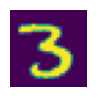

In [4]:
img = Image.open(path/'train'/'3'/'12.png')
show_image(img)

Multiplication of top 3*3 pixel of image with the kernel

In [5]:
tensor_img = tensor(img)  #converting the image into tensor
output = (tensor_img[0:3 , 0:3] * top_edge).sum()
output

tensor(0.)

As we can observe from the above result that, all the pixels in the top left corner are white.

Coloring the cell of a dataframe based on the numerical value inside the cell.

In [6]:
df = pd.DataFrame(tensor_img[:10,:20])
df.style.set_properties(**{'font-size':'6pt'}).background_gradient('Greys')

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,12,99,91,142,155,246,182,155,155,155,155,131,52,0,0,0,0
6,0,0,0,138,254,254,254,254,254,254,254,254,254,254,254,252,210,122,33,0
7,0,0,0,220,254,254,254,235,189,189,189,189,150,189,205,254,254,254,75,0
8,0,0,0,35,74,35,35,25,0,0,0,0,0,0,13,224,254,254,153,0
9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,90,254,254,247,53,0


Top edge

In [7]:
output_1 = (tensor_img[4:7 , 6:9] * top_edge).sum()
output_1

tensor(762.)

Right edge corner

In [8]:
output_2 = (tensor_img[7:10 , 17:20] * top_edge).sum()
output_2

tensor(-29.)

Function to multiply matrix with the filter


In [9]:
def apply_filter(row, col, kernel):
    #making 3 * 3 matrix from given index of row and column
    return (tensor_img[row - 1:row + 2 , col - 1: col + 2] * kernel).sum()
apply_filter(5,7,top_edge)    

tensor(762.)

Example of coordinate grid

In [10]:
[[(i,j) for j in range(1,5)] for i in range(1,5)]

[[(1, 1), (1, 2), (1, 3), (1, 4)],
 [(2, 1), (2, 2), (2, 3), (2, 4)],
 [(3, 1), (3, 2), (3, 3), (3, 4)],
 [(4, 1), (4, 2), (4, 3), (4, 4)]]

<Axes: >

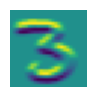

In [11]:
top_edge_3 = [[apply_filter(i,j,top_edge) for j in range(1,27)] for i in range(1,27)]
show_image(top_edge_3)

In [12]:
left_edge = tensor([[-1,1,0],
                    [-1,1,0],
                    [-1,1,0]
                   ]).float()


<Axes: >

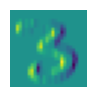

In [13]:
left_edge_3 = [[apply_filter(i,j,left_edge) for j in range(1,27)] for i in range(1,27)]
show_image(left_edge_3)

Convolutions in pytorch

Stacking all the detectors allows multiple kernels (filters) to be applied simultaneously to a batch of images, where each kernel detects a different pattern of pixel intensity changes (such as horizontal edges, vertical edges, and diagonal edges).

In [14]:
diag1_edge = tensor([[0,-1,1], #first diagonal edge
                     [-1,1,0],
                     [1,0,0]]).float()
diag2_edge = tensor([[1,-1,0],  #second diagonal edge
                     [0,1,-1],
                     [0,0,1]]).float()
edge_kernels = torch.stack([left_edge, top_edge, diag1_edge, diag2_edge])
edge_kernels.shape

torch.Size([4, 3, 3])

Our edge_kernels has 4 type of edge detectors, and a (3 x 3) row-col

In [15]:
mnist = DataBlock((ImageBlock(cls=PILImageBW), CategoryBlock),   #our input is image and our output is label
                  get_items=get_image_files,                     #path where we extract the data from  
                  splitter=GrandparentSplitter(),                #way of splitting of data into training and validation dataset
                  get_y=parent_label)                            #our target label 

dls = mnist.dataloaders(path)     #loading the data from a given path
x,y = first(dls.valid)                                         #training data and the target labels from validation dataset
x.shape

torch.Size([64, 1, 28, 28])

As we can observe that the batch size is 64 number of images, 1 channel (RGB), and height and width of image is (28 x 28).

In [16]:
edge_kernels = edge_kernels.unsqueeze(1)
edge_kernels.shape

torch.Size([4, 1, 3, 3])

making the edge kernels to be on the same device as that of training data and also we need the edge kernels to be of rank-4 tensors, so unsqueezing 1 to represent that number of channel is 1. 

In [17]:
edge_kernels = edge_kernels.to(x.device)

In [18]:
batch_features = F.conv2d(x,edge_kernels)    #here edge kernels denote the weight tensor of our model
batch_features.shape

torch.Size([64, 4, 26, 26])

We can observe that there are 64 images in this batch, 4 kernels and 26x26 edge maps

<Axes: >

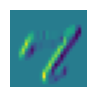

In [19]:
show_image(batch_features[0,0])

Creating a CNN

In [20]:
simple_net = nn.Sequential(
    nn.Linear(28*28,30),
    nn.ReLU(),
    nn.Linear(30,1)
)

In [21]:
simple_net

Sequential(
  (0): Linear(in_features=784, out_features=30, bias=True)
  (1): ReLU()
  (2): Linear(in_features=30, out_features=1, bias=True)
)

Architecture of CNN

In [22]:
broken_cnn = sequential(
    nn.Conv2d(1,30,kernel_size = 3,padding = 1),  #number of channel in this layer is 1, and 30 number of kernels, 
    nn.ReLU(),
    nn.Conv2d(30,1,kernel_size = 3, padding = 1)
).to(x.device)
broken_cnn(x).shape

torch.Size([64, 1, 28, 28])

Convulutional nn with relu activation

In [23]:
def conv(ni,nf,ks = 3, act = True):
    res = nn.Conv2d(ni, nf, stride = 2,kernel_size = ks, padding = ks//2)  #here ni represents the number of input channels, nf represents the number of filters
    if act: res = nn.Sequential(res,nn.ReLU())
    return res    
        


Simple CNN model

In [24]:
simple_cnn = sequential(
    conv(1,4),
    conv(4,8),
    conv(8,16),
    conv(16,32),
    conv(32,2,act = False),
    Flatten(),
).to(x.device)

In [25]:
simple_cnn(x).shape

torch.Size([64, 2])

Our model's learner

In [26]:
learn = Learner(dls,simple_cnn,loss_func = F.cross_entropy, metrics = accuracy)
learn.summary()

<div></div>

Sequential (Input shape: 64 x 1 x 28 x 28)
Layer (type)         Output Shape         Param #    Trainable 
                     64 x 4 x 14 x 14    
Conv2d                                    40         True      
ReLU                                                           
____________________________________________________________________________
                     64 x 8 x 7 x 7      
Conv2d                                    296        True      
ReLU                                                           
____________________________________________________________________________
                     64 x 16 x 4 x 4     
Conv2d                                    1168       True      
ReLU                                                           
____________________________________________________________________________
                     64 x 32 x 2 x 2     
Conv2d                                    4640       True      
ReLU                                          

Training the model

In [27]:
learn.fit_one_cycle(5, 0.01)

epoch,train_loss,valid_loss,accuracy,time
0,0.087784,0.073833,0.974485,00:03
1,0.032293,0.024724,0.991659,00:03
2,0.015648,0.017515,0.995093,00:03
3,0.007532,0.008009,0.999509,00:03
4,0.002328,0.007849,0.999019,00:03


In [28]:
m = learn.model[0]  #our very first layer of neural network model
m

Sequential(
  (0): Conv2d(1, 4, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (1): ReLU()
)

In [29]:
m[0].weight #weight in the very first neural network model
m[0].weight.shape

torch.Size([4, 1, 3, 3])

As the very first layer has 4 outputs, and as the bias is ignored during multiplication, so right now its 4 * 1 * 3 * 3 which is 36 number of parameters even though 40 number of paramters was shown in the summary.

In [30]:
m[0].bias  #bias in the very first layer of neural network

Parameter containing:
tensor([ 0.1514,  0.0020, -0.0136, -0.3179], device='cuda:0', requires_grad=True)

In [31]:
preds, targets = learn.get_preds()
print('The first five predictions are:', preds[:5].argmax(dim=1))
print('The first five targets are:', targets[:5])


The first five predictions are: tensor([1, 1, 1, 1, 1])
The first five targets are: tensor([1, 1, 1, 1, 1])


Color Images

In [32]:
im = image2tensor(Image.open(image_bear()))
im.shape

torch.Size([3, 1000, 846])

<Axes: >

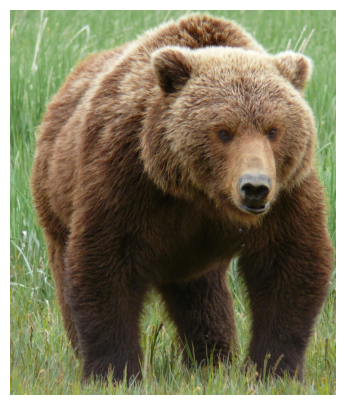

In [33]:
show_image(im)

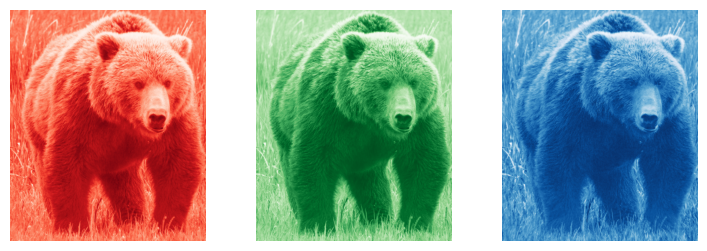

In [36]:
fig , axs = subplots(1,3)
for channel , ax , color in zip(im,axs,('Reds','Greens','Blues')):
    show_image(255 - channel,ax=ax, cmap = color)
    

Improving Training Stability

In [38]:
path = untar_data(URLs.MNIST)
path.ls()

<div><progress max="15683414" value="15687680"></progress> 100.03% [15687680/15683414 00:00&lt;00:00]</div>

[Path('/root/.fastai/data/mnist_png/testing'), Path('/root/.fastai/data/mnist_png/training')]

Function to load the data

In [39]:
def get_dls(bs = 64):
    return DataBlock(
        blocks = (ImageBlock(cls = PILImageBW), CategoryBlock),
        get_items = get_image_files,
        splitter = GrandparentSplitter('training','testing'),
        get_y = parent_label,
        batch_tfms = Normalize()
    ).dataloaders(path, bs = bs)
dls = get_dls()    
    

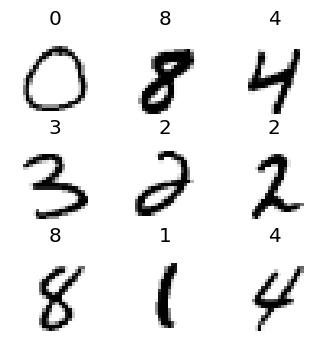

In [44]:
dls.show_batch(figsize = (4,4))

In [49]:
def simple_cnn():
    return sequential(
        conv(1,8,ks = 5),
        conv(8,16),
        conv(16,32),
        conv(32,64),
        conv(64,10,act = False),
        Flatten()
    )

In [50]:
from fastai.callback.hook import *

Training the model

In [51]:
def fit(epochs = 1):
    learn = Learner(dls, simple_cnn(), loss_func =F.cross_entropy, metrics = accuracy, cbs = ActivationStats(with_hist=True))
    learn.fit(epochs , 0.06)
    return learn
    

In [53]:
learn = fit()

epoch,train_loss,valid_loss,accuracy,time
0,2.309421,2.305126,0.113500,00:19


Plot of mean and std in neural network

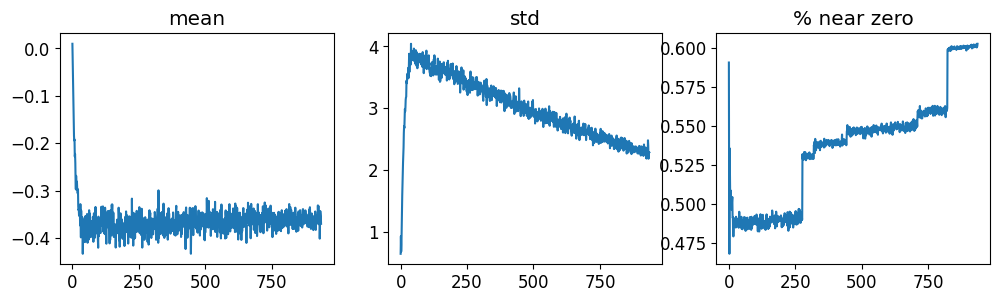

In [54]:
learn.activation_stats.plot_layer_stats(0)

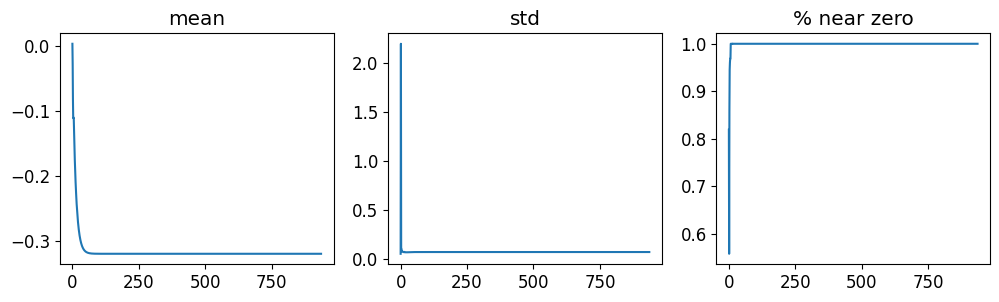

In [55]:
learn.activation_stats.plot_layer_stats(-2)

In [56]:
dls = get_dls(512)
dls


In [57]:
learn = fit()

epoch,train_loss,valid_loss,accuracy,time
0,0.416369,0.227260,0.925600,00:14


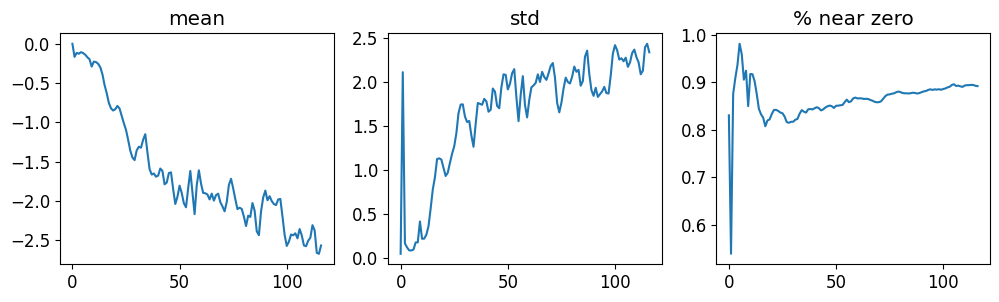

In [58]:
learn.activation_stats.plot_layer_stats(-2)
